In [1]:
import json
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim

from PIL import Image
from tqdm import tqdm

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

SPLIT_DIR = BASE_DIR / "data" / "splits"
MODEL_DIR = BASE_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Using device: cuda
GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [3]:
train_df = pd.read_csv(SPLIT_DIR / "train.csv")
val_df = pd.read_csv(SPLIT_DIR / "val.csv")
test_df = pd.read_csv(SPLIT_DIR / "test.csv")

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (24266, 11)
Validation: (5200, 11)
Test: (5201, 11)


In [4]:
target_col = "season"

print(train_df[target_col].value_counts())

season
Summer    11930
Fall       6351
Winter     5160
Spring      825
Name: count, dtype: int64


In [5]:
classes = sorted(train_df[target_col].unique())

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(classes)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

num_classes = len(classes)

print("Classes:", num_classes)
print(class_to_idx)

with open(MODEL_DIR / "season_class_to_idx.json", "w") as f:
    json.dump(class_to_idx, f, indent=4)

Classes: 4
{'Fall': 0, 'Spring': 1, 'Summer': 2, 'Winter': 3}


In [6]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
class WardrobeDataset(Dataset):

    def __init__(self, dataframe, class_to_idx, target_col, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.class_to_idx = class_to_idx
        self.target_col = target_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        row = self.df.iloc[index]

        image_path = row["image_path"]

        label_name = row[self.target_col]

        label = self.class_to_idx[label_name]

        try:
            image = Image.open(image_path).convert("RGB")

        except Exception:
            image = Image.new("RGB", (224,224), color=(255,255,255))

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)

In [8]:
BATCH_SIZE = 32

train_dataset = WardrobeDataset(
    train_df,
    class_to_idx,
    target_col,
    transform=train_transform
)

val_dataset = WardrobeDataset(
    val_df,
    class_to_idx,
    target_col,
    transform=eval_transform
)

test_dataset = WardrobeDataset(
    test_df,
    class_to_idx,
    target_col,
    transform=eval_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))

Train batches: 759


In [9]:
model = models.mobilenet_v2(
    weights=models.MobileNet_V2_Weights.DEFAULT
)

model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model = model.to(device)

print("Season model ready.")

Season model ready.


In [10]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [11]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(loader):

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [12]:
def evaluate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in tqdm(loader):

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [13]:
EPOCHS = 5

best_val_acc = 0.0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

best_model_path = MODEL_DIR / "mobilenetv2_season_best.pth"

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-"*40)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:

        best_val_acc = val_acc

        torch.save(model.state_dict(), best_model_path)

        print("Best season model saved.")

print("\nTraining completed.")

print("Best validation accuracy:", best_val_acc)


Epoch 1/5
----------------------------------------


100%|████████████████████| 163/163 [00:23<00:00,  6.89it/s]


Train Loss: 0.7848 | Train Acc: 0.6638
Val Loss: 0.6882 | Val Acc: 0.7144
Best season model saved.

Epoch 2/5
----------------------------------------


100%|████████████████████| 163/163 [00:18<00:00,  8.66it/s]


Train Loss: 0.6529 | Train Acc: 0.7286
Val Loss: 0.6488 | Val Acc: 0.7331
Best season model saved.

Epoch 3/5
----------------------------------------


...

Train Loss: 0.5944 | Train Acc: 0.7561
Val Loss: 0.6172 | Val Acc: 0.7475
Best season model saved.

Epoch 4/5
----------------------------------------


100%|████████████████████| 163/163 [00:19<00:00,  8.54it/s]


Train Loss: 0.5517 | Train Acc: 0.7797
Val Loss: 0.5925 | Val Acc: 0.7635
Best season model saved.

Epoch 5/5
----------------------------------------


100%|████████████████████| 163/163 [00:20<00:00,  8.08it/s]

Train Loss: 0.5081 | Train Acc: 0.7972
Val Loss: 0.6135 | Val Acc: 0.7592

Training completed.
Best validation accuracy: 0.7634615384615384


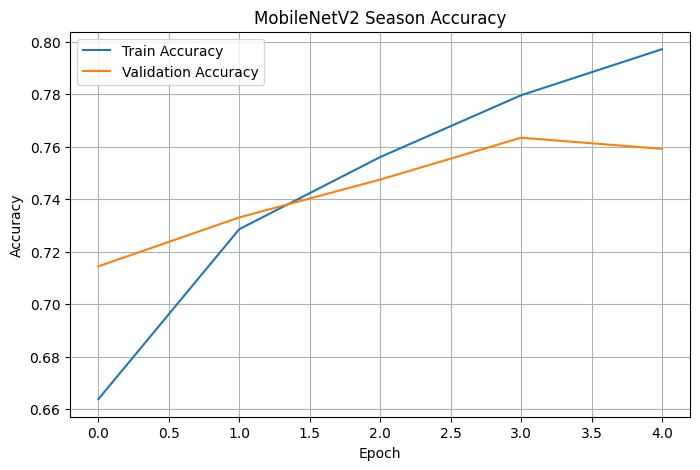

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")

plt.title("MobileNetV2 Season Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid(True)

plt.show()

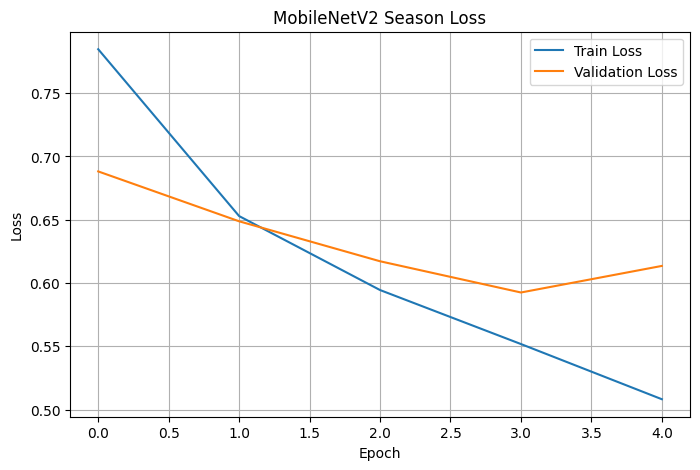

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")

plt.title("MobileNetV2 Season Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()